# ETAPA 2: Análisis exploratorio y perfilado
# Objetivo: Explorar la evolución de los datos y realizar análisis comparativos.
# Rango temporal: 6 meses de datos (enero–junio 2020).
## Dificultad: Media – combinar múltiples archivos y realizar cálculos agregados. bold text

1. ¿Cuáles son los 10 países con más casos confirmados acumulados durante el semestre?

In [67]:
import pandas as pd

url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv'
time_series_covid19_confirmed_global = pd.read_csv(url,on_bad_lines='skip')

In [68]:
totalPaisConfirmados = time_series_covid19_confirmed_global.groupby('Country/Region')['6/30/20'].sum().sort_values(ascending=False)
top10 = totalPaisConfirmados.head(10)
print('Top 10 países con más casos confirmados acumulados al 2020-06-30:')
display(top10.reset_index().rename(columns={'6/30/20':'Confirmado acumulado'}))

Top 10 países con más casos confirmados acumulados al 2020-06-30:


,Country/Region,Confirmado acumulado
0,US,2648797
1,Brazil,1412669
2,Russia,646929
3,India,585481
4,United Kingdom,285213
5,Peru,285213
6,Chile,279393
7,Spain,249271
8,Italy,240578
9,Iran,227662


2. ¿Qué países presentan mayor tasa de letalidad (Deaths / Confirmed * 100)?

In [69]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv'
time_series_covid19_deaths_global = pd.read_csv(url,on_bad_lines='skip')

In [70]:
totalPaisMuertes = time_series_covid19_deaths_global.groupby('Country/Region')['6/30/20'].sum().sort_values(ascending=False)
totalPaisMuertes

Country/Region
US                      127432
Brazil                   59792
United Kingdom           56284
Peru                     37898
Italy                    34767
                         ...  
Uganda                       0
Tuvalu                       0
Vanuatu                      0
Vietnam                      0
Winter Olympics 2022         0
Name: 6/30/20, Length: 201, dtype: int64

In [71]:
tabla_letalidad = pd.merge(totalPaisConfirmados,totalPaisMuertes, on='Country/Region',how='outer')
tabla_letalidad['tasa_letalidad'] = tabla_letalidad['6/30/20_x'] / tabla_letalidad['6/30/20_y']
tabla_letalidad = tabla_letalidad.rename(columns={'6/30/20_x': "Confirmados", '6/30/20_y': "Muertes"})
tabla_letalidad.sort_values(by='tasa_letalidad', ascending=True)

,Confirmados,Muertes,tasa_letalidad
Country/Region,,,
Yemen,1158,312,3.711538
MS Zaandam,9,2,4.500000
United Kingdom,285213,56284,5.067390
Belgium,61427,9747,6.302144
France,204244,29846,6.843262
...,...,...,...
Summer Olympics 2020,0,0,NaN
Tonga,0,0,NaN
Tuvalu,0,0,NaN


3. ¿Cuántos países no registran recuperados en los datos analizados?

In [72]:
url = 'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/refs/heads/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv'
time_series_covid19_recovered_global = pd.read_csv(url,on_bad_lines='skip')

In [73]:
#Revisar bien porque cuenta todos los 0, no solo los del recuperado, es una serie
totalRecuperadosPais = time_series_covid19_recovered_global.groupby('Country/Region')['6/30/20'].sum()
NoRecuperados = (totalRecuperadosPais == 0).sum()
print('En total hay ',NoRecuperados,' paises que no registran recuperados en esos 6 meses')

En total hay  16  paises que no registran recuperados en esos 6 meses


4. ¿Qué país latinoamericano presenta la mayor cantidad de casos activos en junio 2020?

In [159]:
tablaActivos = pd.merge(tabla_letalidad,totalRecuperadosPais, on='Country/Region',how='outer')
tablaActivos = tablaActivos.rename(columns={'6/30/20': "Recuperados"})
tablaActivos['Activos'] = (tablaActivos['Confirmados'] - tablaActivos['Muertes'] - tablaActivos['Recuperados']).clip(lower=0)
mayorActivos = tablaActivos['Activos'].idxmax()
print('El pais latinoamericano con la mayor cantidad de casos activoe en junio del 2020 es',mayorActivos)

El pais latinoamericano con la mayor cantidad de casos activoe en junio del 2020 es US


5. ¿Cómo evolucionaron los casos confirmados en Chile entre enero y junio? (gráfico de
líneas).

In [106]:
datosChile = time_series_covid19_confirmed_global.loc[time_series_covid19_confirmed_global['Country/Region'] == 'Chile']
fechas = datosChile.columns[4:]
valores = datosChile.iloc[0, 4:]

df_evolucion = pd.DataFrame({'Fecha': fechas, 'Valores': valores})
df_evolucion['Fecha'] = pd.to_datetime(df_evolucion['Fecha'], format='%m/%d/%y')
df_evolucion = df_evolucion[(df_evolucion['Fecha'] >= '2020-01-01') & (df_evolucion['Fecha'] <= '2020-06-30')]

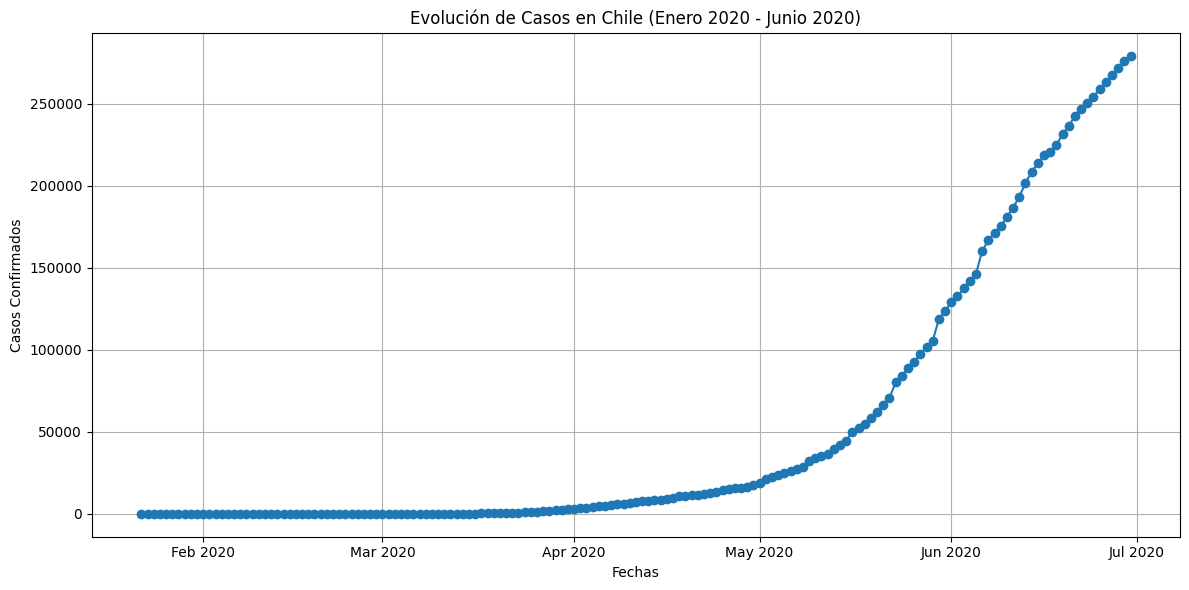

In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(df_evolucion['Fecha'], df_evolucion['Valores'], marker='o')

#para mostrar solo los meses, ya que con todas las fechas no se ve bien
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) 
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Un marcador por mes

plt.title('Evolución de Casos en Chile (Enero 2020 - Junio 2020)')
plt.xlabel('Fechas')
plt.ylabel('Casos Confirmados')
plt.grid()
plt.tight_layout()
plt.show()

6. ¿Cuál fue la fecha con más nuevos casos a nivel mundial durante este período?

In [158]:
casosNuevos = time_series_covid19_confirmed_global.copy()
cols_info = ['Country/Region']
casosNuevos6meses = casosNuevos[cols_info + list(casosNuevos.loc[:, '1/22/20':'6/30/20'].columns)]


casosNuevos6meses.iloc[:, 4:] = casosNuevos6meses.iloc[:, 4:].diff(axis=1).fillna(0).astype(int) # el diff calcula la diferencia entre el mismo dia y el anterior
casosNuevosTotal = casosNuevos6meses.sum(numeric_only=True)
fechaMayorCasosNuevos = casosNuevosTotal.idxmax()
print('El',fechaMayorCasosNuevos,'fue la fecha con mayor casos nuevos confirmados')





El 6/26/20 fue la fecha con mayor casos nuevos confirmados
